In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\jessi\Downloads\cleaned_preprocessed_disaster_data.csv")

df.head()

,iso3,country,disaster_type,year,deaths,affected,mng_cap,inventory,distance,priority_tier
0,BRA,Brazil,Flood,2018,4.0,250.0,4.247241,1664,120,Moderate
1,USA,United States of America,Wildfire,2002,0.0,1572.0,7.704286,1817,218,Low
2,RWA,Rwanda,Flood,2022,3.0,0.0,6.391964,662,448,Moderate
3,USA,United States of America,Drought,2024,0.0,0.0,5.591951,211,187,Critical
4,IDN,Indonesia,Road,2022,10.0,20.0,2.936112,705,434,Critical


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16752 entries, 0 to 16751
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso3           16752 non-null  object 
 1   country        16752 non-null  object 
 2   disaster_type  16752 non-null  object 
 3   year           16752 non-null  int64  
 4   deaths         16752 non-null  float64
 5   affected       16752 non-null  float64
 6   mng_cap        16752 non-null  float64
 7   inventory      16752 non-null  int64  
 8   distance       16752 non-null  int64  
 9   priority_tier  16752 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 1.3+ MB


iso3             0
country          0
disaster_type    0
year             0
deaths           0
affected         0
mng_cap          0
inventory        0
distance         0
priority_tier    0
dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder

le_iso = LabelEncoder()
le_country = LabelEncoder()
le_disaster = LabelEncoder()
le_priority = LabelEncoder()

df['iso3'] = le_iso.fit_transform(df['iso3'])
df['country'] = le_country.fit_transform(df['country'])
df['disaster_type'] = le_disaster.fit_transform(df['disaster_type'])
df['priority_tier'] = le_priority.fit_transform(df['priority_tier'])

In [5]:
X = df.drop("priority_tier", axis=1)
y = df["priority_tier"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(X_test)

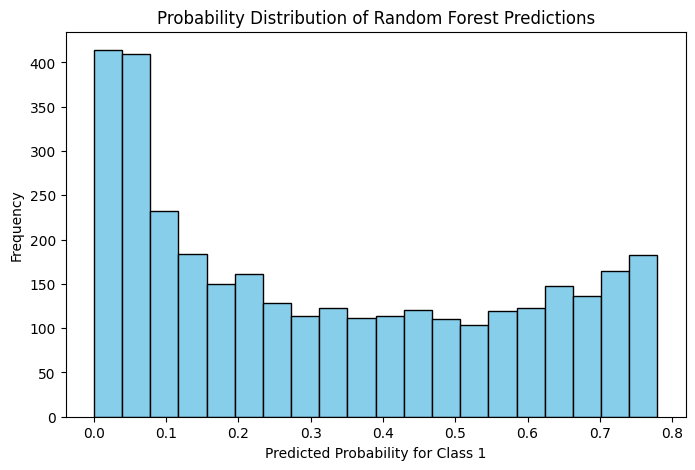

In [10]:
import matplotlib.pyplot as plt
import numpy as np

y_prob = model.predict_proba(X_test)

probabilities = y_prob[:, 1]

plt.figure(figsize=(8,5))
plt.hist(probabilities, bins=20, color='skyblue', edgecolor='black')

plt.title("Probability Distribution of Random Forest Predictions")
plt.xlabel("Predicted Probability for Class 1")
plt.ylabel("Frequency")

plt.show()

In [11]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[0.68918231 0.04699984 0.26381785]
 [0.72657314 0.03681855 0.23660831]
 [0.01837012 0.7578992  0.22373068]
 [0.57424532 0.0903061  0.33544858]
 [0.11891719 0.47572836 0.40535445]]


In [12]:
print(model.classes_)
print(le_priority.classes_)

[0 1 2]
['Critical' 'Low' 'Moderate']


In [13]:
def adjust_priority(prob):

    critical_prob = prob[0]
    low_prob = prob[1]
    moderate_prob = prob[2]

    if critical_prob > 0.85:
        return 0
    elif moderate_prob > 0.50:
        return 2
    else:
        return 1

In [14]:
adjusted_pred = [adjust_priority(p) for p in probabilities]

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.5762458967472396
